<a href="https://colab.research.google.com/github/Skhelshiaty/CS4082-Machine-Learning-Labs/blob/main/Lab2_ML_Sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 1 — Setting Up the Environment**

**Step 1: Create the notebook**

**Step 2: Check libraries**

In [3]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

import numpy as np
import matplotlib.pyplot as plt

print("All libraries loaded successfully!")


scikit-learn version: 1.6.1
All libraries loaded successfully!


**Part 2 — Loading and Exploring the Iris Dataset**

Step 3: Load the Iris dataset

In [4]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data      # features
y = iris.target   # labels


Step 4: Print basic dataset info

In [5]:
print(f"Feature names: {iris.feature_names}")
print(f"Target names: {iris.target_names}")
print(f"Data shape: {X.shape}")
print(f"First 3 rows:\n{X[:3]}")


Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
First 3 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


**Step 5: Sepal scatter plot (quick visualization)**

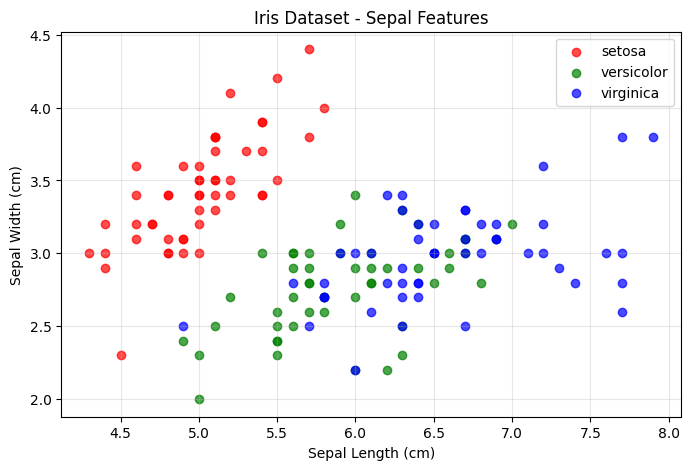

In [6]:
plt.figure(figsize=(8, 5))
colors = ['red', 'green', 'blue']

for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1], color=colors[i], label=name, alpha=0.7)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Iris Dataset - Sepal Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Task 1.1: First 10 rows of X and y side-by-side

In [7]:
print("--- First 10 rows of X and y side by side ---")
combined = np.hstack((X[:10], y[:10].reshape(-1, 1)))
print(combined)


--- First 10 rows of X and y side by side ---
[[5.1 3.5 1.4 0.2 0. ]
 [4.9 3.  1.4 0.2 0. ]
 [4.7 3.2 1.3 0.2 0. ]
 [4.6 3.1 1.5 0.2 0. ]
 [5.  3.6 1.4 0.2 0. ]
 [5.4 3.9 1.7 0.4 0. ]
 [4.6 3.4 1.4 0.3 0. ]
 [5.  3.4 1.5 0.2 0. ]
 [4.4 2.9 1.4 0.2 0. ]
 [4.9 3.1 1.5 0.1 0. ]]


**Task 1.2: Class distribution**

In [8]:
print("\n--- Class Distribution ---")
unique, counts = np.unique(y, return_counts=True)
print("Classes:", unique)
print("Counts:", counts)



--- Class Distribution ---
Classes: [0 1 2]
Counts: [50 50 50]


**Task 1.3: Petal scatter plot**

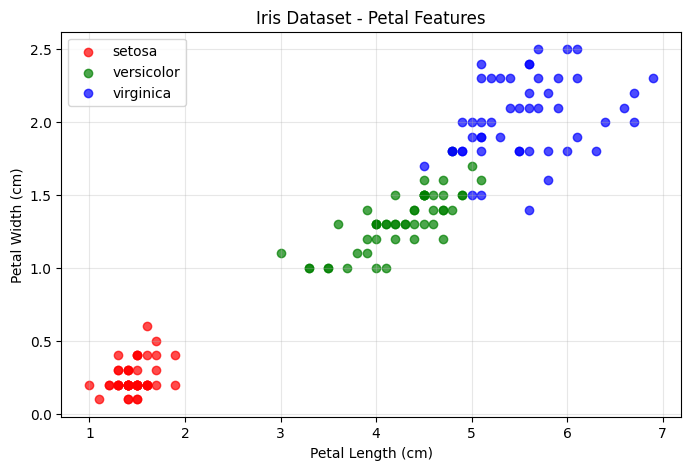

In [9]:
plt.figure(figsize=(8, 5))
colors = ['red', 'green', 'blue']

for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X[mask, 2], X[mask, 3], color=colors[i], label=name, alpha=0.7)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Dataset - Petal Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Part 3 — Train/Test Split**

Step 6: Split the dataset (80% / 20%) with stratification

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


**Task 2 — Verify the Split**

Task 2.1: Print shapes + class balance

In [11]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nClass distribution in y_train (with stratify):")
print(np.unique(y_train, return_counts=True))


X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)

Class distribution in y_train (with stratify):
(array([0, 1, 2]), array([40, 40, 40]))


Task 2.2: Remove stratify and compare

In [12]:
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Without stratify:")
print("Train:", np.unique(y_train_u, return_counts=True))
print("Test:", np.unique(y_test_u, return_counts=True))


Without stratify:
Train: (array([0, 1, 2]), array([40, 41, 39]))
Test: (array([0, 1, 2]), array([10,  9, 11]))


**Part 4 — Training Models**

**Step 7: Decision Tree model**

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print("Decision Tree predictions (first 10):")
print(dt_predictions[:10])
print("Actual labels:")
print(y_test[:10])


Decision Tree predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]
Actual labels:
[0 2 1 1 0 1 0 0 2 1]


**Step 8: KNN model**

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

print("KNN predictions (first 10):")
print(knn_predictions[:10])


KNN predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]


**Task 3 — Compare Predictions**

In [15]:
for k in [3, 10]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    print(f"KNN (k={k}) first 10 predictions:", preds[:10])


KNN (k=3) first 10 predictions: [0 2 1 1 0 1 0 0 2 1]
KNN (k=10) first 10 predictions: [0 2 1 1 0 1 0 0 2 1]


**Part 5 — Evaluating Model Performance**

**Step 9: Accuracy**

In [16]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))
print("KNN Accuracy:", accuracy_score(y_test, knn_predictions))


Decision Tree Accuracy: 0.9333333333333333
KNN Accuracy: 1.0


**Step 10: Classification Report**

In [17]:
from sklearn.metrics import classification_report

print("Decision Tree Report")
print(classification_report(y_test, dt_predictions, target_names=iris.target_names))

print("KNN Report")
print(classification_report(y_test, knn_predictions, target_names=iris.target_names))


Decision Tree Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

KNN Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Step 11: Confusion Matrices**

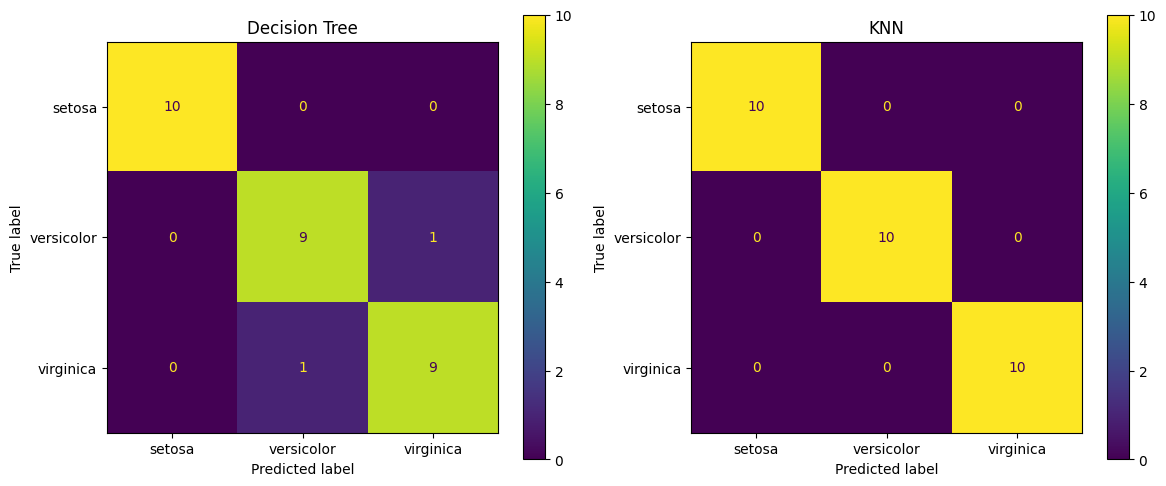

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, dt_predictions),
    display_labels=iris.target_names
).plot(ax=axes[0])
axes[0].set_title("Decision Tree")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, knn_predictions),
    display_labels=iris.target_names
).plot(ax=axes[1])
axes[1].set_title("KNN")

plt.tight_layout()
plt.show()


Task 4: Compare the Models

1) Which model achieved higher accuracy?

The KNN model achieved higher accuracy than the Decision Tree model.
KNN reached 100% accuracy, while the Decision Tree achieved 93.33% accuracy on the test set.
This indicates that KNN classified all test samples correctly, whereas the Decision Tree made a small number of misclassifications.

2) Which class was hardest to classify? Why?

The Versicolor and Virginica classes were the hardest to classify.
This is evident from the confusion matrix and classification report, where some samples of these two classes were misclassified as each other.
The reason is that Versicolor and Virginica have overlapping feature values, especially in petal length and petal width, making them harder to separate.
In contrast, Setosa was classified perfectly because its features are clearly distinct from the other two classes.

3) In medical diagnosis, which is more important: precision or recall? Why?

In medical diagnosis, recall is usually more important than precision.
High recall ensures that most actual positive cases (e.g., sick patients) are correctly identified.
Missing a sick patient (false negative) can be dangerous, whereas a false positive can often be corrected with further testing.

**Task 5: Predict New Samples**

In [19]:
import numpy as np

flowers = {
    "Flower A": [6.7, 3.0, 5.2, 2.3],
    "Flower B": [5.8, 2.7, 4.1, 1.0],
    "Flower C": [4.9, 3.1, 1.5, 0.1]
}

for name, values in flowers.items():
    sample = np.array([values])
    dt_pred = dt_model.predict(sample)[0]
    knn_pred = knn_model.predict(sample)[0]

    print(
        f"{name} → "
        f"Decision Tree: {iris.target_names[dt_pred]}, "
        f"KNN: {iris.target_names[knn_pred]}"
    )

Flower A → Decision Tree: virginica, KNN: virginica
Flower B → Decision Tree: versicolor, KNN: versicolor
Flower C → Decision Tree: setosa, KNN: setosa




```
Both models were used to predict the class of three new flower samples.
In some cases, the predictions matched, while in others they differed.
Since KNN achieved higher accuracy earlier, its predictions are considered more reliable.



**PART 7 — Working With CSV Data (FINAL SECTION)**

**Step 1: Create a sample CSV file**

In [20]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 100

data = {
    'study_hours': np.round(np.random.uniform(1, 10, n), 1),
    'attendance_pct': np.round(np.random.uniform(40, 100, n), 1),
    'assignments': np.random.randint(3, 10, n),
    'passed': np.random.choice([0, 1], n, p=[0.35, 0.65])
}

df = pd.DataFrame(data)
df.to_csv('students.csv', index=False)

print("CSV file created")
df.head()

CSV file created


,study_hours,attendance_pct,assignments,passed
0,4.4,41.9,6,0
1,9.6,78.2,5,1
2,7.6,58.9,3,1
3,6.4,70.5,6,1
4,2.4,94.5,8,1


**Step 2: Load and explore the CSV**

In [21]:
df = pd.read_csv('students.csv')

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)

print("\nStatistical summary:")
print(df.describe())

print("\nDataset info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Shape: (100, 4)

Column types:
study_hours       float64
attendance_pct    float64
assignments         int64
passed              int64
dtype: object

Statistical summary:
       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000    1.000000
75%       7.600000       85.975000     8.000000    1.000000
max       9.900000       99.100000     9.000000    1.000000

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     100 non-null    float64
 1   attendance_pct  100 non-null   

**Step 3: Prepare features (X) and target (y)**

In [22]:
X = df[['study_hours', 'attendance_pct', 'assignments']].values
y = df['passed'].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", np.unique(y, return_counts=True))

X shape: (100, 3)
y shape: (100,)
Class distribution: (array([0, 1]), array([31, 69]))


**Step 4: Train/Test split (CSV data)**

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (80, 3)
Testing size: (20, 3)


**Step 5: Decision Tree on CSV data**

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_csv = DecisionTreeClassifier(random_state=42)
dt_csv.fit(X_train, y_train)

dt_preds = dt_csv.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print(classification_report(y_test, dt_preds, target_names=['Failed', 'Passed']))

Decision Tree Accuracy: 0.55
              precision    recall  f1-score   support

      Failed       0.33      0.50      0.40         6
      Passed       0.73      0.57      0.64        14

    accuracy                           0.55        20
   macro avg       0.53      0.54      0.52        20
weighted avg       0.61      0.55      0.57        20



**Step 6: KNN on CSV data**

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn_csv = KNeighborsClassifier(n_neighbors=5)
knn_csv.fit(X_train, y_train)

knn_preds = knn_csv.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_preds))
print(classification_report(y_test, knn_preds, target_names=['Failed', 'Passed']))

KNN Accuracy: 0.6
              precision    recall  f1-score   support

      Failed       0.33      0.33      0.33         6
      Passed       0.71      0.71      0.71        14

    accuracy                           0.60        20
   macro avg       0.52      0.52      0.52        20
weighted avg       0.60      0.60      0.60        20



The dataset was explored using describe() and info() to understand its structure and statistics.
Both Decision Tree and KNN models were trained on the CSV data.
The lower accuracy is expected because the dataset is synthetically generated and may not contain strong predictive patterns.
The model with higher accuracy is considered more suitable for predicting student performance.
Adding more relevant features could further improve model performance.